**1) Import Librairies**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

**2) Loading of the dataset**

Cifar10 is a dataset of 50,000 32x32 color training images and 10,000 test images, labeled over 10 categories :

| Classe | Label |
|--------|-------|
| Airplane | 0 |
| Automobile | 1 |
| Bird | 2 |
| Cat | 3 |
| Deer | 4 |
| Dog | 5 |
| Frog | 6 |
| Horse | 7 |
| Ship | 8 |
| Truck | 9 |

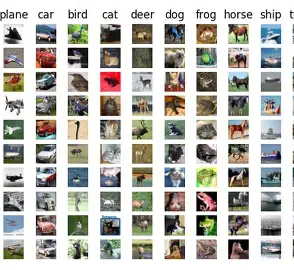

In [ ]:
# Load CIFAR-10 dataset (images + labels)
(x_train, y_train), (x_test, y_test) = cifar10.load_data()


**3) Preparation of the dataset**

In [ ]:
# Reshape data to match CNN input format
x_train = x_train.reshape((50000, 32, 32, 3))
x_test  = x_test.reshape((10000, 32, 32, 3))

# Normalize pixel values between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# Convert labels to one-hot encoding
y_train = to_categorical(y_train)
y_test  = to_categorical(y_test)

# Print dataset shapes
print('  X_train:', x_train.shape, '  y_train:', y_train.shape)
print('  X_test :', x_test.shape,  '  y_test :', y_test.shape)

  X_train: (50000, 32, 32, 3)   y_train: (50000, 10)
  X_test : (10000, 32, 32, 3)   y_test : (10000, 10)


**4) CNN**

In [ ]:
# Function to build a simple CNN model
def build_base_model():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),  # Input image

        layers.Conv2D(32, (3, 3), activation='relu'),  # Extract features
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'), # Deeper features
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(), # Convert to 1D vector
        layers.Dense(64, activation='relu'), #fully-connected layer; combines all features.
        layers.Dense(10, activation='softmax') # output layer; one neuron per class, outputs a probability distribution.
    ])

    # Compile model (optimizer + loss + metric)
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
# Build and display model
model = build_base_model()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the base model

start_time = time.time()

history_base = model.fit(x_train, y_train, epochs=20, batch_size=64, validation_split=0.1)

total_time = time.time() - start_time
print(f"Total training time: {total_time:.2f} seconds")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 86ms/step - accuracy: 0.4481 - loss: 1.5341 - val_accuracy: 0.5332 - val_loss: 1.2981
Epoch 2/20
608/704 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.5691 - loss: 1.2198

From epoch 9, the validation loss increases while the training loss continues to decrease, indicating overfitting

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/")

In [ ]:
# Save model and training history
model.save('model.keras')

In [ ]:
import pickle

with open('history.pkl', 'wb') as f:
    pickle.dump(history_base.history, f)

In [ ]:
import tensorflow as tf
import gc

# Clean the memory
tf.keras.backend.clear_session()
del model
gc.collect()

0



# **5) Model to reduce overfitting**

Dropout

In [ ]:
# Model with Dropout to reduce overfitting

model_dropout = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2), # Reduce 20% of the neurons

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2), # Reduce 20% of the neurons
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3), # Reduce 30% of the neurons
    layers.Dense(10, activation='softmax')
])

# Compile and train dropout model

model_dropout.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

start = time.time()
history_dropout = model_dropout.fit(x_train, y_train, epochs=20, batch_size=64, validation_split=0.1)
time_dropout = time.time() - start
print(f"Dropout - temps d'entraînement : {time_dropout:.2f}s")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 71s 95ms/step - accuracy: 0.3674 - loss: 1.7232 - val_accuracy: 0.4900 - val_loss: 1.4293
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.4947 - loss: 1.4058 - val_accuracy: 0.5786 - val_loss: 1.2115
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.5471 - loss: 1.2724 - val_accuracy: 0.6304 - val_loss: 1.0921
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 105ms/step - accuracy: 0.5747 - loss: 1.1932 - val_accuracy: 0.6438 - val_loss: 1.0327
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 99ms/step - accuracy: 0.5979 - loss: 1.1371 - val_accuracy: 0.6562 - val_loss: 0.9850
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 93ms/step - accuracy: 0.6128 - loss: 1.0896 - val_accuracy: 0.6818 - val_loss: 0.9286
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 95ms/step - accuracy: 0.6299 - loss: 1.0518 - val_accuracy: 0.6808 - val_loss: 0.9023
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 97ms/step - accuracy: 0.6416 - loss: 1.0219 

Data augmentation

In [ ]:
# Data augmentation to increase dataset variability

model_aug = build_base_model()

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)
#Manual train/validation split for augmentation
x_train_aug = x_train[:45000]
y_train_aug = y_train[:45000]
x_val_aug   = x_train[45000:]
y_val_aug   = y_train[45000:]

start = time.time()

# Train model with augmented data

history_aug = model_aug.fit(
    datagen.flow(x_train_aug, y_train_aug, batch_size=64),
    epochs=20,
    validation_data=(x_val_aug, y_val_aug)
)
time_aug = time.time() - start
print(f"Data Augmentation - temps d'entraînement : {time_aug:.2f}s")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 119ms/step - accuracy: 0.3881 - loss: 1.6732 - val_accuracy: 0.5128 - val_loss: 1.3562
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.4970 - loss: 1.4057 - val_accuracy: 0.5690 - val_loss: 1.2203
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.5453 - loss: 1.2785 - val_accuracy: 0.5820 - val_loss: 1.2063
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.5766 - loss: 1.1967 - val_accuracy: 0.6300 - val_loss: 1.0579
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 121ms/step - accuracy: 0.6001 - loss: 1.1354 - val_accuracy: 0.6614 - val_loss: 0.9881
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.6149 - loss: 1.0994 - val_accuracy: 0.6522 - val_loss: 1.0114
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 120ms/step - accuracy: 0.6255 - loss: 1.0679 - val_accuracy: 0.6876 - val_loss: 0.9212
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.6359 - loss: 1

# **6) Analyse and Comparaison**

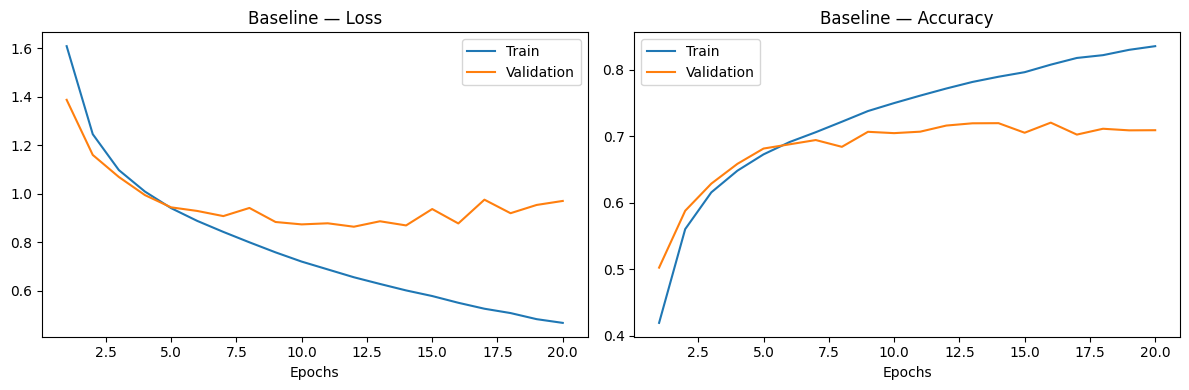

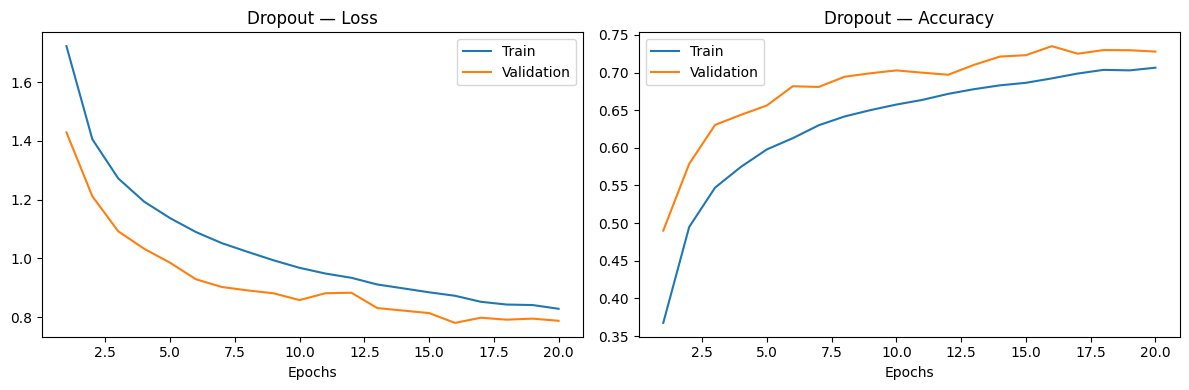

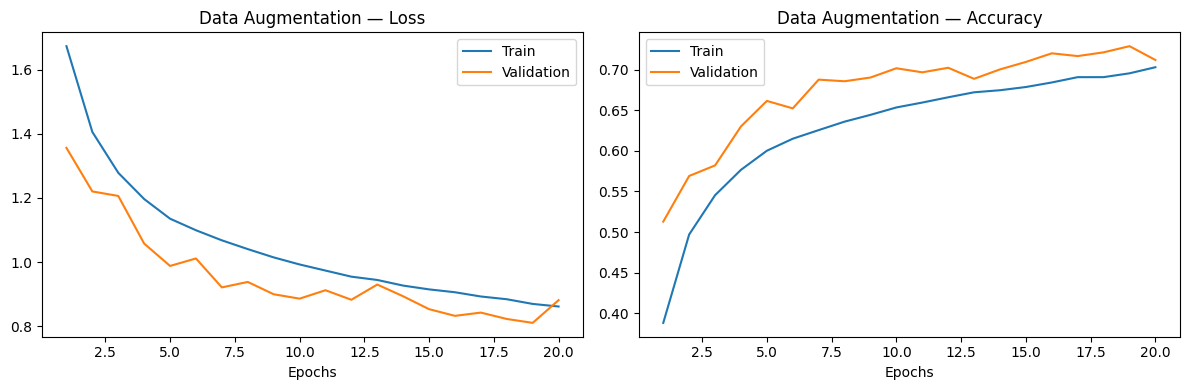

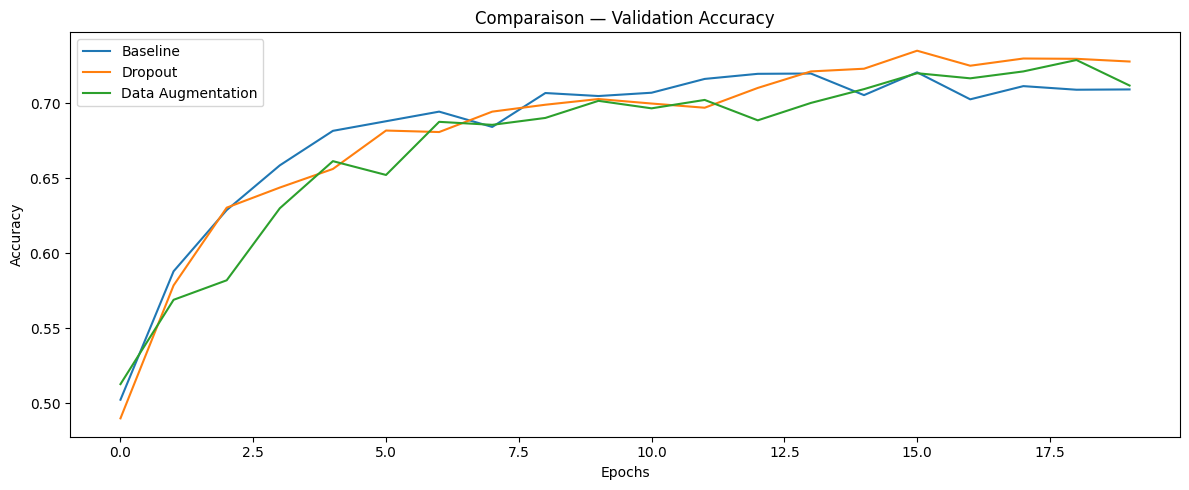

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.1010 - loss: 2.3067
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7148 - loss: 0.8290
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7027 - loss: 0.9009


,Modèle,Test Accuracy,Test Loss,Temps (s),Epochs effectués
0,Baseline,0.1010,2.3067,1517.5,20
1,Dropout,0.7148,0.8290,1451.3,20
2,Data Augmentation,0.7027,0.9009,1754.1,20


In [ ]:
# Function to plot training results

def plot_history(history, title):
    acc     = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss    = history.history['loss']
    val_loss= history.history['val_loss']
    epochs  = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, loss,     label='Train')
    axes[0].plot(epochs, val_loss, label='Validation')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].legend()

    axes[1].plot(epochs, acc,     label='Train')
    axes[1].plot(epochs, val_acc, label='Validation')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_base,     "Baseline")
plot_history(history_dropout,  "Dropout")
plot_history(history_aug,      "Data Augmentation")


# Validation Accuracy

plt.figure(figsize=(12, 5))

for hist, label in [
    (history_base,     'Baseline'),
    (history_dropout,  'Dropout'),
    (history_aug,      'Data Augmentation'),
]:
    plt.plot(hist.history['val_accuracy'], label=label)

plt.title('Comparaison — Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


# Summary table


import pandas as pd

# Evaluate models on test data
res_base     = model.evaluate(x_test, y_test)
res_dropout  = model_dropout.evaluate(x_test, y_test)
res_aug      = model_aug.evaluate(x_test, y_test)

df = pd.DataFrame({
    'Modèle'           : ['Baseline', 'Dropout', 'Data Augmentation'],
    'Test Accuracy'    : [res_base[1], res_dropout[1],
                          res_aug[1]],
    'Test Loss'        : [res_base[0], res_dropout[0],
                          res_aug[0]],
    'Temps (s)'        : [total_time, time_dropout,
                          time_aug],
    'Epochs effectués' : [len(history_base.history['loss']),
                          len(history_dropout.history['loss']),
                          len(history_aug.history['loss']),
                        ],
})

df['Test Accuracy'] = df['Test Accuracy'].map('{:.4f}'.format)
df['Test Loss']     = df['Test Loss'].map('{:.4f}'.format)
df['Temps (s)']     = df['Temps (s)'].map('{:.1f}'.format)

display(df)

In [ ]:

import pickle

model_dropout.save("model_dropout.keras")
model_aug.save("model_data_augmentation.keras")

for hist, name in [
    (history_dropout,  "history_dropout"),
    (history_aug,      "history_data_augmentation"),
]:
    with open(f"{name}.pkl", "wb") as f:
        pickle.dump(hist.history, f)

print("Tous les modèles et historiques ont été sauvegardés.")

Tous les modèles et historiques ont été sauvegardés.
